# Lecture 6 — Data Collection & Preprocessing, Part 2
### AI in Data Science — Chapter 2: End-to-End Machine Learning Project (II)

**Based on:** Aurélien Géron, *Hands-On Machine Learning*, 3rd Edition — Chapter 2, sections "Prepare the Data" through "Select and Train a Model."
**Notebooks/data source:** [github.com/ageron/handson-ml3](https://github.com/ageron/handson-ml3)

We continue directly from Lecture 5's stratified train/test split of the California Housing dataset.

**By the end of this lecture you will be able to:**
1. Clean missing values with `SimpleImputer`
2. Encode categorical/text attributes correctly
3. Fix skewed distributions with a log transform
4. Engineer a geographic *similarity* feature using k-Means + an RBF kernel (a 3rd-edition technique)
5. Write your own custom Scikit-Learn transformer
6. Chain everything into one concise `Pipeline` / `ColumnTransformer`
7. Train and honestly compare several candidate models

---


## 1. Setup & Recap

In [2]:
import numpy as np
import pandas as pd

np.random.seed(42)

print("Importing libraries...")

Importing libraries...


In [2]:
import tarfile, urllib.request
from pathlib import Path

def load_housing_data():
    tarball_path = Path("datasets/housing.tgz")
    if not tarball_path.is_file():
        Path("datasets").mkdir(parents=True, exist_ok=True)
        url = "https://github.com/ageron/data/raw/main/housing.tgz"
        urllib.request.urlretrieve(url, tarball_path)
        with tarfile.open(tarball_path) as housing_tarball:
            housing_tarball.extractall(path="datasets")
    return pd.read_csv(Path("datasets/housing/housing.csv"))

if not Path("housing_train.csv").exists():
    # Fallback: rebuild Lecture 5's exact split if its output isn't available locally
    from sklearn.model_selection import StratifiedShuffleSplit
    full = load_housing_data()
    full["income_cat"] = pd.cut(full["median_income"], bins=[0., 1.5, 3.0, 4.5, 6., np.inf], labels=[1, 2, 3, 4, 5])
    split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
    for tr_i, te_i in split.split(full, full["income_cat"]):
        strat_train_set = full.loc[tr_i].drop("income_cat", axis=1)
        strat_test_set = full.loc[te_i].drop("income_cat", axis=1)
    strat_train_set.to_csv("housing_train.csv", index=False)
    strat_test_set.to_csv("housing_test.csv", index=False)

strat_train_set = pd.read_csv("housing_train.csv")
strat_test_set = pd.read_csv("housing_test.csv")

# Separate predictors from labels — never apply transformations that "see" the label!
housing = strat_train_set.drop("median_house_value", axis=1)
housing_labels = strat_train_set["median_house_value"].copy()
housing.shape, housing_labels.shape


((16512, 9), (16512,))

**Why separate predictors and labels now?** Some data preparation steps (e.g. an imputer's median) must be learned **only from the training predictors**, never from the label — otherwise you leak target information into your features.

## 2. Data Cleaning

Recall from Lecture 5: `total_bedrooms` has missing values. Most ML algorithms cannot handle missing values, so we have three options:
1. Drop the rows with missing values
2. Drop the whole attribute
3. **Fill in the missing values** (zero, mean, median, ...) ← generally preferred, keeps the most information

In [3]:
housing.isna().sum()[housing.isna().sum() > 0]


total_bedrooms    168
dtype: int64

In [4]:
sample_incomplete_rows = housing[housing.isna().any(axis=1)].head(3)
sample_incomplete_rows


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity
99,-120.67,40.50,15.0,5343.0,NaN,2503.0,902.0,3.5962,INLAND
194,-117.96,34.03,35.0,2093.0,NaN,1755.0,403.0,3.4115,<1H OCEAN
249,-118.05,34.04,33.0,1348.0,NaN,1098.0,257.0,4.2917,<1H OCEAN


In [5]:
# Option 1: drop rows        -> housing.dropna(subset=["total_bedrooms"])
# Option 2: drop the column  -> housing.drop("total_bedrooms", axis=1)
# Option 3: impute (our choice below)
median = housing["total_bedrooms"].median()
sample_incomplete_rows["total_bedrooms"].fillna(median)


99     434.0
194    434.0
249    434.0
Name: total_bedrooms, dtype: float64

### 2.1 `SimpleImputer` — the Scikit-Learn way

Doing this by hand for every numeric column is tedious and error-prone in production. `SimpleImputer` learns a statistic (default: median) per column on the *training* data and applies it consistently — including later, on the test set or in production.

In [6]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="median")

housing_num = housing.drop("ocean_proximity", axis=1)  # imputer needs numeric data only
imputer.fit(housing_num)
imputer.statistics_


array([-118.51  ,   34.26  ,   29.    , 2125.    ,  434.    , 1167.    ,
        408.    ,    3.5385])

In [7]:
X = imputer.transform(housing_num)
housing_tr = pd.DataFrame(X, columns=housing_num.columns, index=housing_num.index)
housing_tr.loc[sample_incomplete_rows.index]


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income
99,-120.67,40.50,15.0,5343.0,434.0,2503.0,902.0,3.5962
194,-117.96,34.03,35.0,2093.0,434.0,1755.0,403.0,3.4115
249,-118.05,34.04,33.0,1348.0,434.0,1098.0,257.0,4.2917


> **Fit vs. transform — the golden rule:** `imputer.fit(...)` learns statistics from the **training set only**. `imputer.transform(...)` can then be reapplied identically to the test set or new production data — never re-`fit` on test data.

## 3. Handling Text and Categorical Attributes

In [8]:
housing_cat = housing[["ocean_proximity"]]
housing_cat.value_counts()


ocean_proximity
<1H OCEAN          7274
INLAND             5301
NEAR OCEAN         2089
NEAR BAY           1846
ISLAND                2
Name: count, dtype: int64

### 3.1 `OrdinalEncoder` — be careful!

Most ML algorithms want numbers, not text. `OrdinalEncoder` maps each category to an integer — but this silently implies an **order** (0 < 1 < 2 < 3 < 4) that doesn't exist between `"INLAND"` and `"NEAR BAY"`. A model may learn that categories which are numerically close are "similar" — which is meaningless here.

In [9]:
from sklearn.preprocessing import OrdinalEncoder

ordinal_encoder = OrdinalEncoder()
housing_cat_encoded = ordinal_encoder.fit_transform(housing_cat)
housing_cat_encoded[:5], ordinal_encoder.categories_


(array([[3.],
        [0.],
        [1.],
        [1.],
        [4.]]),
 [array(['<1H OCEAN', 'INLAND', 'ISLAND', 'NEAR BAY', 'NEAR OCEAN'],
        dtype=object)])

### 3.2 `OneHotEncoder` — the safe default for unordered categories

One binary column per category. No false ordering is implied. The trade-off: more columns (fine here, only 5 categories; can be a problem with high-cardinality categorical variables).

In [10]:
from sklearn.preprocessing import OneHotEncoder

cat_encoder = OneHotEncoder()
housing_cat_1hot = cat_encoder.fit_transform(housing_cat)
housing_cat_1hot  # sparse matrix — efficient when most entries are 0


<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 16512 stored elements and shape (16512, 5)>

In [11]:
pd.DataFrame(
    housing_cat_1hot.toarray()[:5],
    columns=cat_encoder.categories_[0],
)


,<1H OCEAN,INLAND,ISLAND,NEAR BAY,NEAR OCEAN
0,0.0,0.0,0.0,1.0,0.0
1,1.0,0.0,0.0,0.0,0.0
2,0.0,1.0,0.0,0.0,0.0
3,0.0,1.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,1.0


## 4. Fixing Skewed Distributions with a Log Transform

Recall from Lecture 5's histograms: `total_rooms`, `total_bedrooms`, `population`, and `households` are all heavily **right-skewed** (a long tail of large values). Many models (especially linear ones) work best when features are closer to a symmetric, bell-shaped distribution. A simple, effective fix: apply a **log transform**.

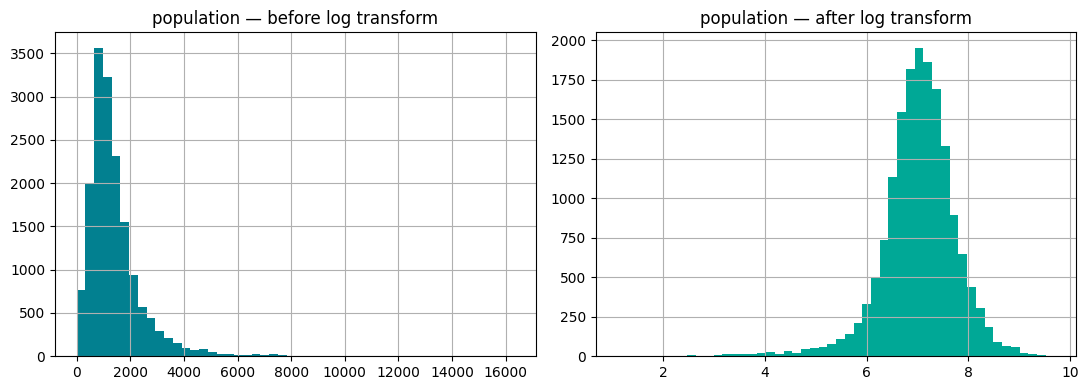

In [12]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
housing["population"].hist(bins=50, ax=axes[0], color="#028090")
axes[0].set_title("population — before log transform")
np.log(housing["population"]).hist(bins=50, ax=axes[1], color="#00A896")
axes[1].set_title("population — after log transform")
plt.tight_layout()
plt.show()


The log-transformed distribution is far closer to symmetric. We'll apply this transform inside our pipeline using `FunctionTransformer`, which wraps any plain NumPy function into a proper Scikit-Learn transformer:

```python
from sklearn.preprocessing import FunctionTransformer
log_transformer = FunctionTransformer(np.log, feature_names_out="one-to-one")
log_pop = log_transformer.transform(housing[["population"]])
```

We'll wire this into the full pipeline in Section 6.

## 5. Geographic Similarity Features (a 3rd-Edition Technique)

In Lecture 5 we saw that price clusters strongly around certain locations (e.g. near the coast, near big cities). Rather than feeding raw `latitude`/`longitude` into a linear model (which struggles with this kind of spatial pattern), the book's 3rd edition introduces a clever trick: measure **how similar each district is to a handful of geographic "hot spots"**, using k-Means to find the hot spots and a **Gaussian RBF kernel** to turn distance into a similarity score between 0 and 1.

In [13]:
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.cluster import KMeans
from sklearn.metrics.pairwise import rbf_kernel

class ClusterSimilarity(BaseEstimator, TransformerMixin):
    """For each sample, computes RBF-kernel similarity to each of n_clusters
    k-Means cluster centers. Output: one similarity column per cluster (0 = far, 1 = right at the center)."""

    def __init__(self, n_clusters=10, gamma=1.0, random_state=None):
        self.n_clusters = n_clusters
        self.gamma = gamma
        self.random_state = random_state

    def fit(self, X, y=None, sample_weight=None):
        self.kmeans_ = KMeans(self.n_clusters, n_init=10, random_state=self.random_state)
        self.kmeans_.fit(X, sample_weight=sample_weight)
        return self

    def transform(self, X):
        return rbf_kernel(X, self.kmeans_.cluster_centers_, gamma=self.gamma)

    def get_feature_names_out(self, names=None):
        return [f"Cluster {i} similarity" for i in range(self.n_clusters)]


In [14]:
cluster_simil = ClusterSimilarity(n_clusters=10, gamma=1., random_state=42)
similarities = cluster_simil.fit_transform(
    housing[["latitude", "longitude"]], sample_weight=housing_labels)
similarities[:3].round(2)


array([[0.08, 0.  , 0.6 , 0.  , 0.  , 0.99, 0.  , 0.  , 0.  , 0.14],
       [0.  , 0.99, 0.  , 0.04, 0.  , 0.  , 0.11, 0.  , 0.63, 0.  ],
       [0.44, 0.  , 0.3 , 0.  , 0.  , 0.7 , 0.  , 0.01, 0.  , 0.29]])

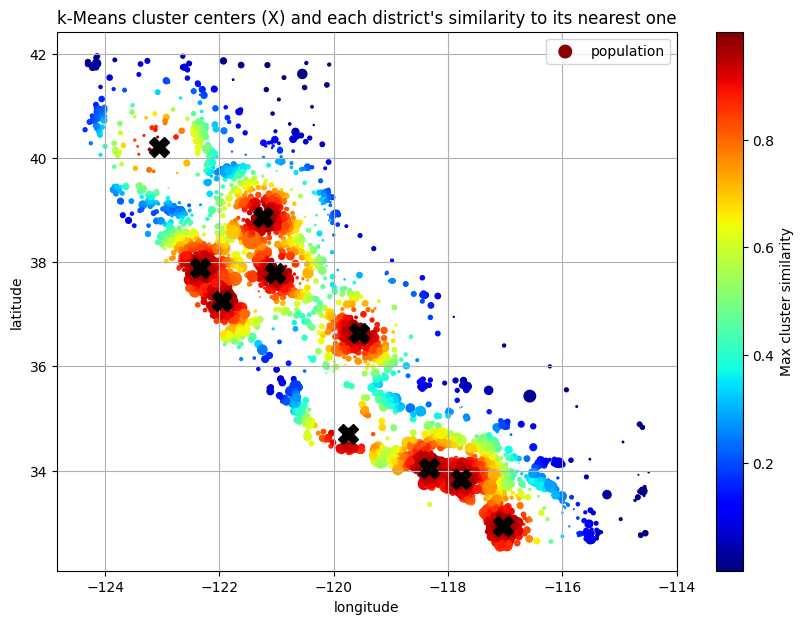

In [15]:
housing_renamed = housing.copy()
housing_renamed["Max cluster similarity"] = similarities.max(axis=1)

housing_renamed.plot(
    kind="scatter", x="longitude", y="latitude", grid=True,
    s=housing["population"] / 100, label="population",
    c="Max cluster similarity", cmap="jet", colorbar=True,
    legend=True, sharex=False, figsize=(10, 7),
)
plt.plot(cluster_simil.kmeans_.cluster_centers_[:, 1],
         cluster_simil.kmeans_.cluster_centers_[:, 0],
         linestyle="", color="black", marker="X", markersize=14)
plt.title("k-Means cluster centers (X) and each district's similarity to its nearest one")
plt.show()


Notice how `sample_weight=housing_labels` biases the k-Means centers toward **expensive** districts — the clusters found aren't just "where districts are dense," but "where expensive districts are concentrated," which is a more useful signal for predicting price. This transformer is a great example of Lecture 4's *model-based vs. instance-based* distinction blurring together: we're using an unsupervised model (k-Means) purely as a feature-engineering step inside a supervised pipeline.

## 6. Custom Transformers, Generalized

`ClusterSimilarity` above is one example of a custom transformer (introduced conceptually in Lecture 5's spirit, now put to real use). The same recipe — implement `fit()` + `transform()`, inherit `BaseEstimator` + `TransformerMixin` — works for any feature-engineering idea, including the attribute-combination step from Lecture 5 (`rooms_per_household`, `population_per_household`, `bedrooms_per_room`).

In [16]:
rooms_ix, bedrooms_ix, population_ix, households_ix = 3, 4, 5, 6

class CombinedAttributesAdder(BaseEstimator, TransformerMixin):
    # Adds rooms_per_household and population_per_household always;
    # bedrooms_per_room only if add_bedrooms_per_room=True (a tunable hyperparameter).

    def __init__(self, add_bedrooms_per_room=True):
        self.add_bedrooms_per_room = add_bedrooms_per_room

    def fit(self, X, y=None):
        return self  # nothing to learn

    def transform(self, X):
        rooms_per_household = X[:, rooms_ix] / X[:, households_ix]
        population_per_household = X[:, population_ix] / X[:, households_ix]
        if self.add_bedrooms_per_room:
            bedrooms_per_room = X[:, bedrooms_ix] / X[:, rooms_ix]
            return np.c_[X, rooms_per_household, population_per_household, bedrooms_per_room]
        return np.c_[X, rooms_per_household, population_per_household]

attr_adder = CombinedAttributesAdder(add_bedrooms_per_room=True)
housing_extra_attribs = attr_adder.transform(housing_num.values)
housing_extra_attribs.shape


(16512, 11)

Because `add_bedrooms_per_room` (and `n_clusters`, `gamma` for `ClusterSimilarity`) are constructor arguments, they all become **tunable hyperparameters** you can search over with `GridSearchCV` later in the course.

## 7. Feature Scaling

Look at the numeric ranges: `total_rooms` can be in the thousands, `median_income` is roughly 0–15. Most ML algorithms (gradient descent–based models, SVMs, k-NN, neural nets) perform poorly when features are on very different scales.

| Method | Formula | Range | Sensitive to outliers? |
|---|---|---|---|
| **Min-max scaling** (`MinMaxScaler`) | (x − min) / (max − min) | [0, 1] | Yes — a single extreme outlier compresses everything else |
| **Standardization** (`StandardScaler`) | (x − mean) / std | unbounded, mean 0, std 1 | Much less |

> **Golden rule again:** fit the scaler on the **training data only**, then use it to transform both train and test/production data.

In [17]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
housing_num_scaled = scaler.fit_transform(housing_num)
pd.DataFrame(housing_num_scaled, columns=housing_num.columns).describe().loc[["mean", "std"]].round(2)


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income
mean,-0.0,0.0,-0.0,-0.0,0.0,0.0,0.0,0.0
std,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


## 8. Transformation Pipelines — the Concise 3rd-Edition Style

Running each step by hand is error-prone and hard to reproduce identically on new data. Scikit-Learn's `Pipeline` chains steps into a single object. The 3rd edition also introduces `make_pipeline()` and `make_column_transformer()` — convenience functions that auto-name each step, so you don't have to invent string names for every single one.

In [18]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import FunctionTransformer

# A pipeline for the heavily-skewed count columns: impute -> log-transform -> scale
log_pipeline = make_pipeline(
    SimpleImputer(strategy="median"),
    FunctionTransformer(np.log, feature_names_out="one-to-one"),
    StandardScaler(),
)

# A pipeline for "ordinary" numeric columns: impute -> scale
default_num_pipeline = make_pipeline(
    SimpleImputer(strategy="median"),
    StandardScaler(),
)

# A pipeline for the categorical column: impute (most frequent) -> one-hot encode
cat_pipeline = make_pipeline(
    SimpleImputer(strategy="most_frequent"),
    OneHotEncoder(handle_unknown="ignore"),
)

# The geographic similarity pipeline, using our custom transformer
cluster_simil_pipeline = ClusterSimilarity(n_clusters=10, gamma=1., random_state=42)

print("Pipelines built:", "log_pipeline, default_num_pipeline, cat_pipeline, cluster_simil_pipeline")


Pipelines built: log_pipeline, default_num_pipeline, cat_pipeline, cluster_simil_pipeline


In [19]:
from sklearn.compose import make_column_selector, make_column_transformer

log_attribs = ["total_bedrooms", "total_rooms", "population", "households"]
cat_attribs = ["ocean_proximity"]
cluster_attribs = ["latitude", "longitude"]

# Every other numeric column not explicitly listed falls through to default_num_pipeline
preprocessing = make_column_transformer(
    (log_pipeline, log_attribs),
    (cluster_simil_pipeline, cluster_attribs),
    (cat_pipeline, cat_attribs),
    remainder=default_num_pipeline,  # apply this to all remaining numeric columns
)

housing_prepared = preprocessing.fit_transform(housing, housing_labels)
housing_prepared.shape


(16512, 21)

One call — `preprocessing.fit_transform(housing, housing_labels)` — now does *everything*: log-transforming skewed counts, computing geographic similarity, one-hot encoding categories, imputing and scaling everything else, all combined into a single feature matrix. Note that `housing_labels` is passed in only because `ClusterSimilarity` optionally uses it as a *sample weight* for k-Means — it is never used as a *feature*, preserving the golden rule from Lecture 5-6.

In [20]:
preprocessing.get_feature_names_out()[:15]


array(['pipeline-1__total_bedrooms', 'pipeline-1__total_rooms',
       'pipeline-1__population', 'pipeline-1__households',
       'clustersimilarity__Cluster 0 similarity',
       'clustersimilarity__Cluster 1 similarity',
       'clustersimilarity__Cluster 2 similarity',
       'clustersimilarity__Cluster 3 similarity',
       'clustersimilarity__Cluster 4 similarity',
       'clustersimilarity__Cluster 5 similarity',
       'clustersimilarity__Cluster 6 similarity',
       'clustersimilarity__Cluster 7 similarity',
       'clustersimilarity__Cluster 8 similarity',
       'clustersimilarity__Cluster 9 similarity',
       'pipeline-2__ocean_proximity_<1H OCEAN'], dtype=object)

## 9. Select and Train a Model

With a clean, fully numeric feature matrix in hand, we can finally train models. Following the *No Free Lunch* theorem from Lecture 4, we try more than one and compare them honestly.

In [21]:
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline as make_pipe

lin_reg = make_pipe(preprocessing, LinearRegression())
lin_reg.fit(housing, housing_labels)

housing_predictions = lin_reg.predict(housing)
housing_predictions[:5].round(-2), housing_labels.iloc[:5].values


(array([250400., 376600., 120300.,  99300., 315600.]),
 array([458300., 483800., 101700.,  96100., 361800.]))

In [22]:
from sklearn.metrics import mean_squared_error

lin_rmse = mean_squared_error(housing_labels, housing_predictions, squared=False) \
    if False else np.sqrt(mean_squared_error(housing_labels, housing_predictions))
print(f"Linear Regression training RMSE: ${lin_rmse:,.0f}")


Linear Regression training RMSE: $64,844


In [23]:
from sklearn.tree import DecisionTreeRegressor

tree_reg = make_pipe(preprocessing, DecisionTreeRegressor(random_state=42))
tree_reg.fit(housing, housing_labels)

tree_predictions = tree_reg.predict(housing)
tree_rmse = np.sqrt(mean_squared_error(housing_labels, tree_predictions))
print(f"Decision Tree training RMSE: ${tree_rmse:,.0f}")


Decision Tree training RMSE: $0


A training RMSE near \$0 for the Decision Tree looks amazing — until you recall Lecture 4's overfitting warning. This is almost certainly **severe overfitting**, not a great model. We must not trust training-set error. Let's validate honestly with **k-fold cross-validation**.

In [24]:
from sklearn.model_selection import cross_val_score

def display_cv_rmse(name, model):
    scores = cross_val_score(model, housing, housing_labels,
                              scoring="neg_mean_squared_error", cv=10)
    rmse_scores = np.sqrt(-scores)
    print(f"{name:20s} — CV RMSE mean: ${rmse_scores.mean():,.0f}   std: ${rmse_scores.std():,.0f}")

display_cv_rmse("Linear Regression", lin_reg)
display_cv_rmse("Decision Tree", tree_reg)


Linear Regression    — CV RMSE mean: $64,958   std: $1,578


Decision Tree        — CV RMSE mean: $66,687   std: $1,733


With honest cross-validated evaluation, the Decision Tree's real generalization error is revealed — usually **no better than, and often worse than**, plain Linear Regression on this dataset, despite its ~\$0 training error. Let's also try a **Random Forest**, an ensemble of many decision trees, which tends to reduce overfitting by averaging many trees' predictions.

In [25]:
from sklearn.ensemble import RandomForestRegressor

forest_reg = make_pipe(preprocessing, RandomForestRegressor(random_state=42))
display_cv_rmse("Random Forest", forest_reg)


Random Forest        — CV RMSE mean: $47,542   std: $712


The Random Forest typically performs noticeably better than either single model — a first hint of why ensemble methods are so popular in practice. *(Full hyperparameter tuning of the Random Forest, via `GridSearchCV` or `RandomizedSearchCV`, is the natural next step — and the topic of the following lecture in this course.)*

---
## 10. Summary

| Step | What we did | Why it matters |
|---|---|---|
| Data cleaning | `SimpleImputer` on missing values | Most models cannot handle NaNs |
| Categorical encoding | `OneHotEncoder` on `ocean_proximity` | Avoids implying a false order |
| Skew correction | Log-transform on long-tailed counts | Helps linear models and stabilizes variance |
| Geographic similarity | k-Means + RBF kernel | Captures spatial price clusters better than raw lat/long |
| Custom transformers | `BaseEstimator` + `TransformerMixin` | Lets feature engineering become tunable hyperparameters |
| Pipelines | `make_pipeline` / `make_column_transformer` | One reproducible call for train, test, and production |
| Model selection | Linear Regression vs. Decision Tree vs. Random Forest, via cross-validation | Never trust training error; the *No Free Lunch* theorem says try several models |

